In [86]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [102]:
project='incTel'
ed='run4/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='tracerDifsmaller'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')

#var='tracer2Difsmall'

#ds2=xr.open_dataset(str(location) +  str(var) + '.nc')

#var='tracer3'

#ds3=xr.open_dataset(str(location) +  str(var) + '.nc')

#var='tracer4'

#ds4=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')

#np.array()
#Take them minus 1 and 2 to skip the boundary


if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
    TIME=ds.T.values #np.array(np.append(np.append(dsb.T.values,ds.T.values),np.append(dsbE.T.values,dsbE2.T.values)))
    Tracer= ds.TRAC01.values #np.array(np.append(np.append(dsb.TRAC01.values,ds.TRAC01.values,axis=0),np.append(dsbE.TRAC01.values,dsbE2.TRAC01.values,axis=0),axis=0))
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]
    TIME=ds.T.values #np.array(np.append(ds1.T.values,ds2.T.values)) #np.array(np.append(np.append(ds1.T.values,ds2.T.values),np.append(ds3.T.values,ds4.T.values)))
    Tracer= ds.TRAC01.values #np.array(np.append(ds1.TRAC01.values,ds2.TRAC01.values,axis=0))#np.array(np.append(np.append(ds1.TRAC01.values,ds2.TRAC01.values,axis=0),np.append(ds3.TRAC01.values,ds4.TRAC01.values,axis=0),axis=0))


ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(TIME)

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [103]:
start=np.where(TIME/(60*60*24*360)>1.5)[0][0]
end =np.where(TIME/(60*60*24*360)<3)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

## Over time 

In [104]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [105]:
closS=20 #int(len(dsG.Y)*0.4)
closE=-20#np.where(dsG.Y>=130000)[0][0] #np.where(dsG.Y>=260000)[0][0]
depS=np.where(dsG.Z>=-400)[0][-1]
depE=np.where(dsG.Z>=-700)[0][-1]

NameError: name 'dsb' is not defined

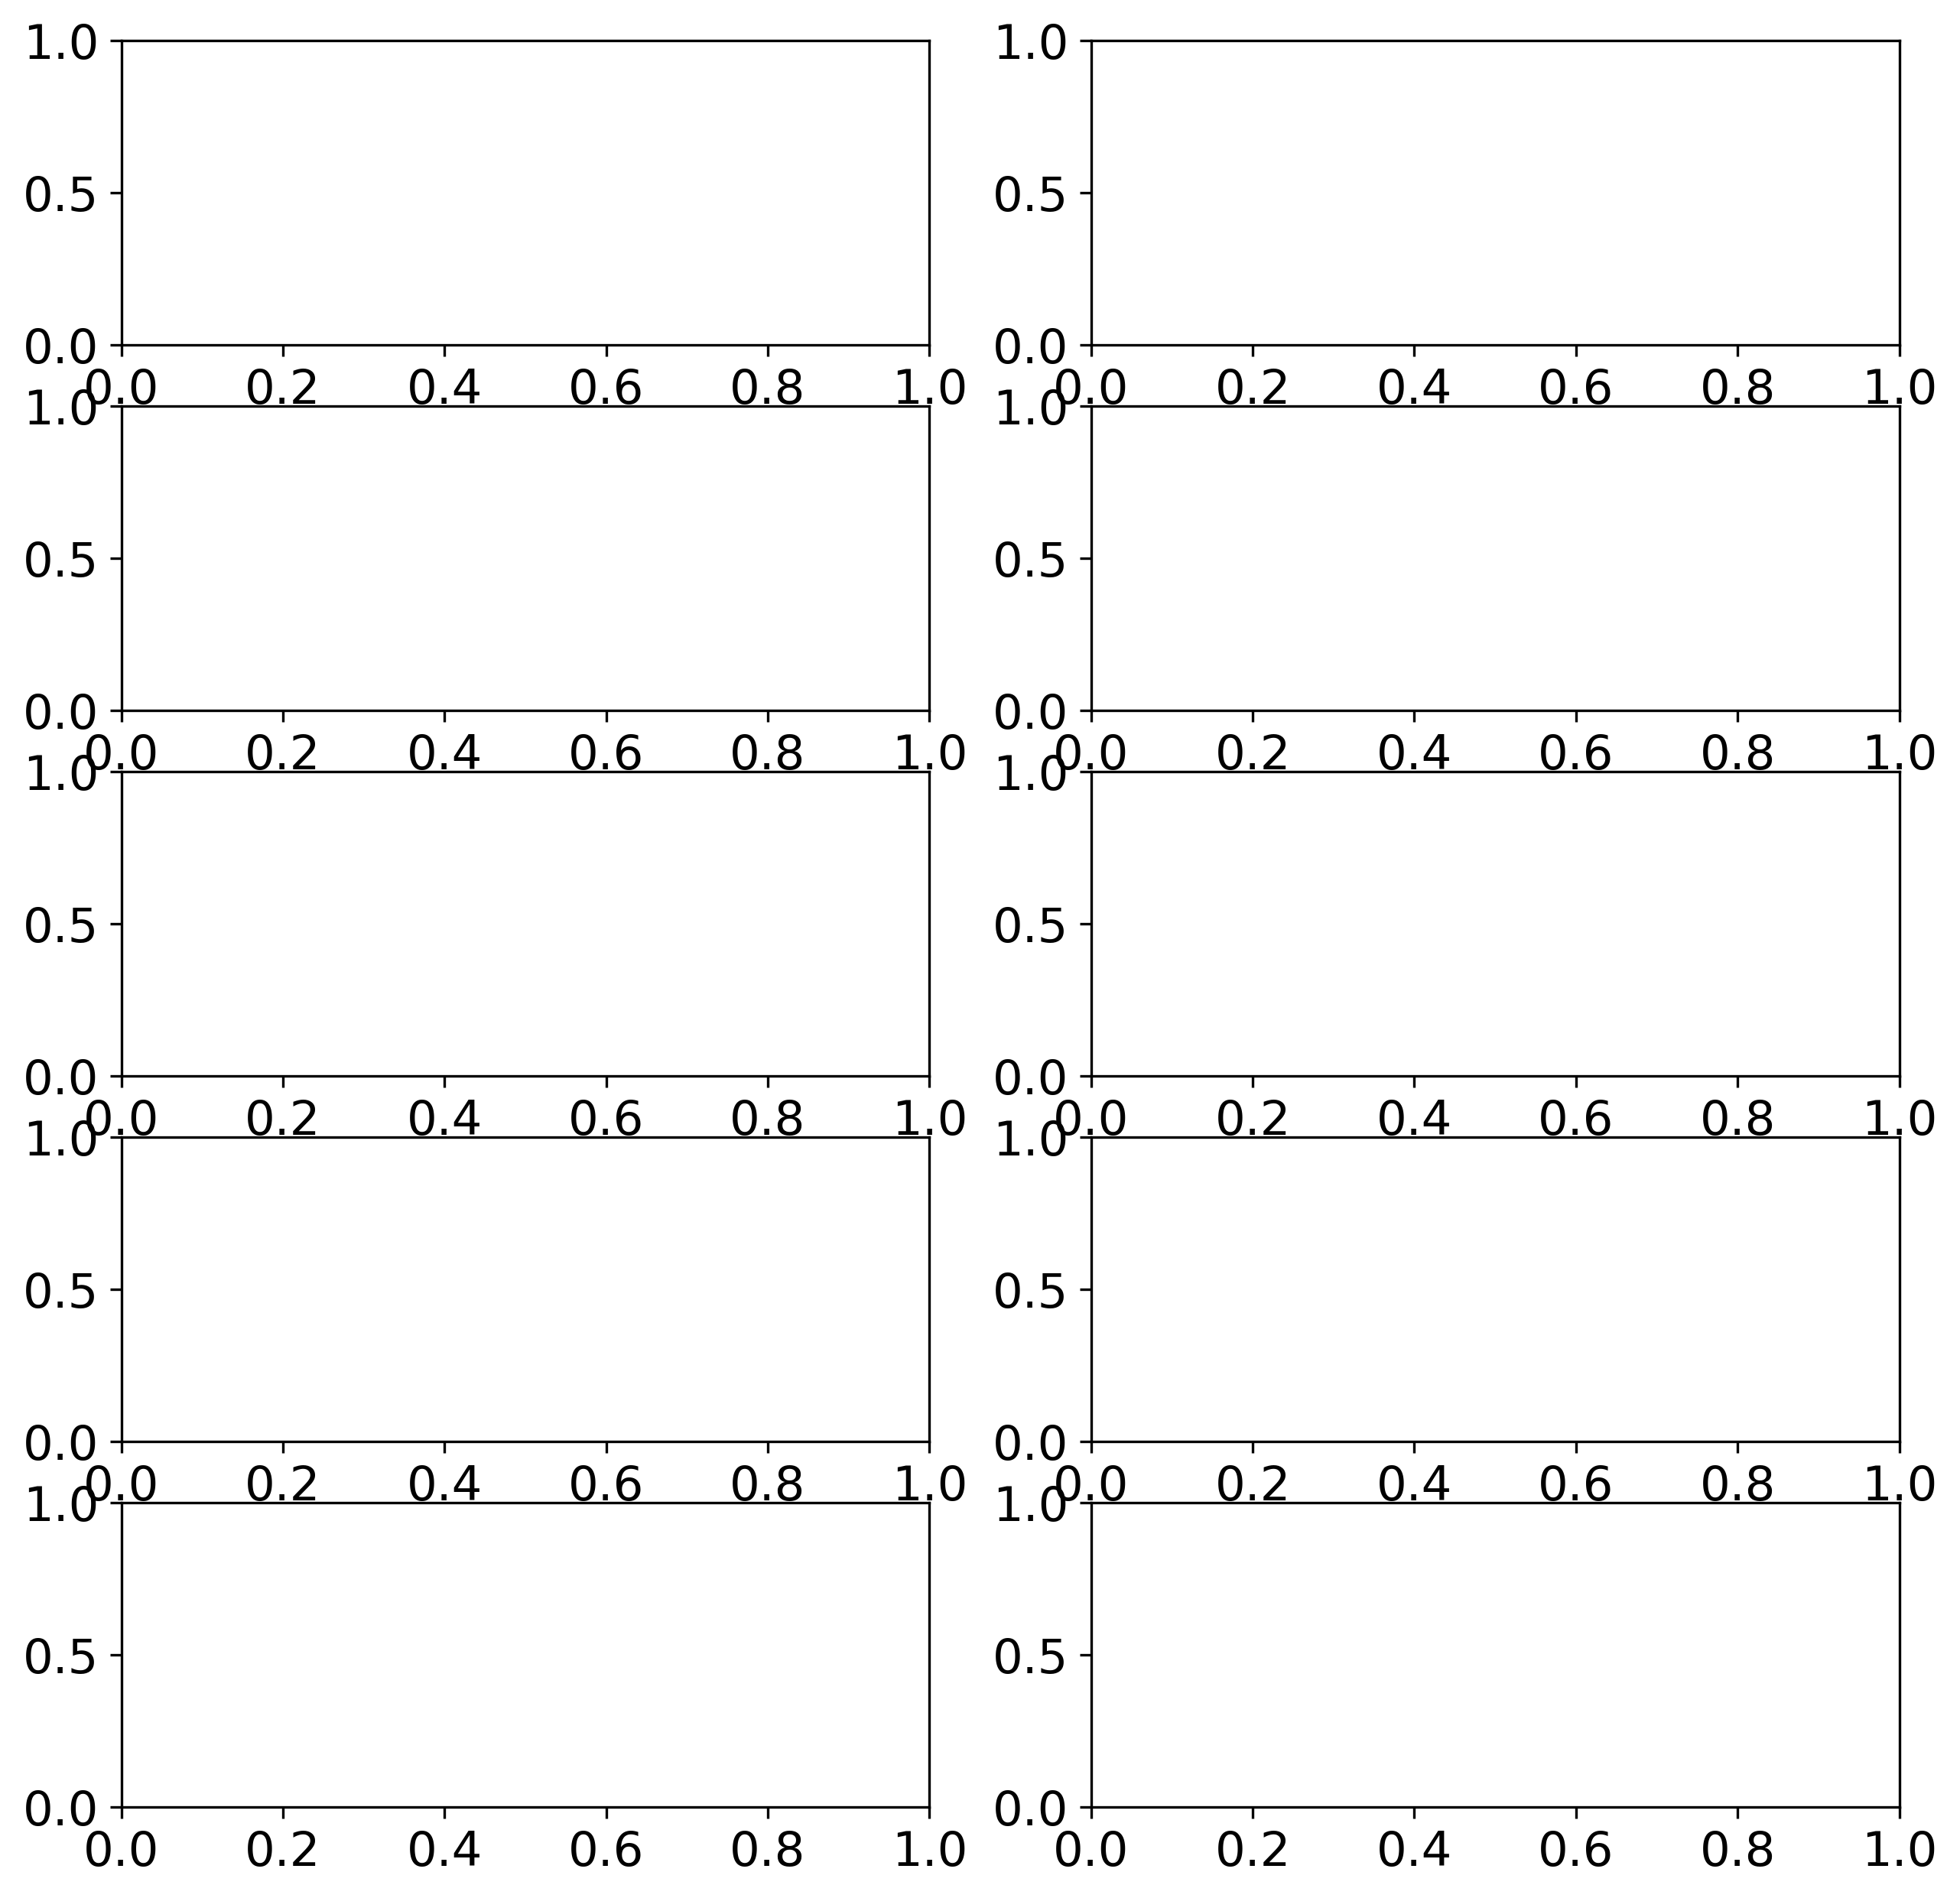

In [91]:
fig,ax = plt.subplots(5,2)

indX=5
start=0
divT=(60*60)
unit= 'Hours'
#Dambreak
tsteps=np.arange(0,nt,int(nt/10)) #np.arange(start,start+len(ds.T[start:end]),len(ds.T[start:end])/10)
levels=np.arange(14,15.2,0.2)

#Heat of surface
#int(tsteps=[0,1,2,3,4,6,8,10,11,12]

### Temperature ###
#vmin=11
#vmax=15

#T=ds.THETA[:,:,:,indX]
#Yin=dsG.Y[OBp:OBendp]
#Zin=dsG.Z

#cmapi=cmocean.cm.thermal
#maskin=mask[:,OBp:OBendp,indX]
#levels=[11,12,13,13.5,14,15]
#clab='Temperature [degC]'

### Velocity ###
maskin=mask[:,OBp:OBendp,indX]

T=np.mean(np.array(np.append(dsb.TRAC01.values,ds.TRAC01.values,axis=0))[:,:,:,OBx:OBendx],axis=3)
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=0
vmax=1
cmapi=cmocean.cm.turbid

clab='Meridional velocity [cm/s]'

levels=[0]


axin=ax[0,0]
tin=int(tsteps[0])
timein=(TIME[tin]-TIME[start])/divT 
axin.set(ylabel='Depth [m]',title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[0,1]

tin=int(tsteps[1])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[1,0]

tin=int(tsteps[2])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[1,1]

tin=int(tsteps[3])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[2,0]

tin=int(tsteps[4])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[2,1]

tin=int(tsteps[5])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[3,0]

tin=int(tsteps[6])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[3,1]

tin=int(tsteps[7])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[4,0]

tin=int(tsteps[8])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]',xlabel='Distance in y [km]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski'or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[4,1]

tin=int(tsteps[9])
timein=(TIME[tin]-TIME[start])/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),xlabel='Distance in y [km]' )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

if project =='OpenNorth' or project =='Orlanski' or project =='mixing' or project =='telescopico':
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
    axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text(0.82, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
else:
    axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

#axin.axvline(dsG.Y[int(len(dsG.Y)*0.4)]/1000)
#fig.suptitle(f'{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}\n Max temp: {np.max(np.ma.masked_array(ds.THETA[tin,:,OB:OBend,OBx+1:OBendx-1],mask=mask[:,OB:OBend,OBx+1:OBendx-1])):.1f}°C')

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(clab)

#axin.axvline(dsG.Y[int(len(dsG.Y)*0.4)]/1000)
#axin.axvline(dsG.Y[int(len(dsG.Y)*0.4)]/1000)
#axin.axvline(dsG.Y[int(len(dsG.Y)*0.45)]/1000)

fig.tight_layout()
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'tracer.png', bbox_inches='tight')
plt.show()

In [106]:
def animate(t):
    tt=((TIME[t]-TIME[0])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,indX],mask=mask[:,OBp:OBendp,indX]))
    fig.suptitle(f'After {tt:.1f} days')



In [107]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=4, metadata=dict(artist='AM'), bitrate=2000)

In [108]:
tin=0
divV=1
divU=1
divW=1

In [109]:
params = {'font.size': 15,
          'figure.figsize': (10, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

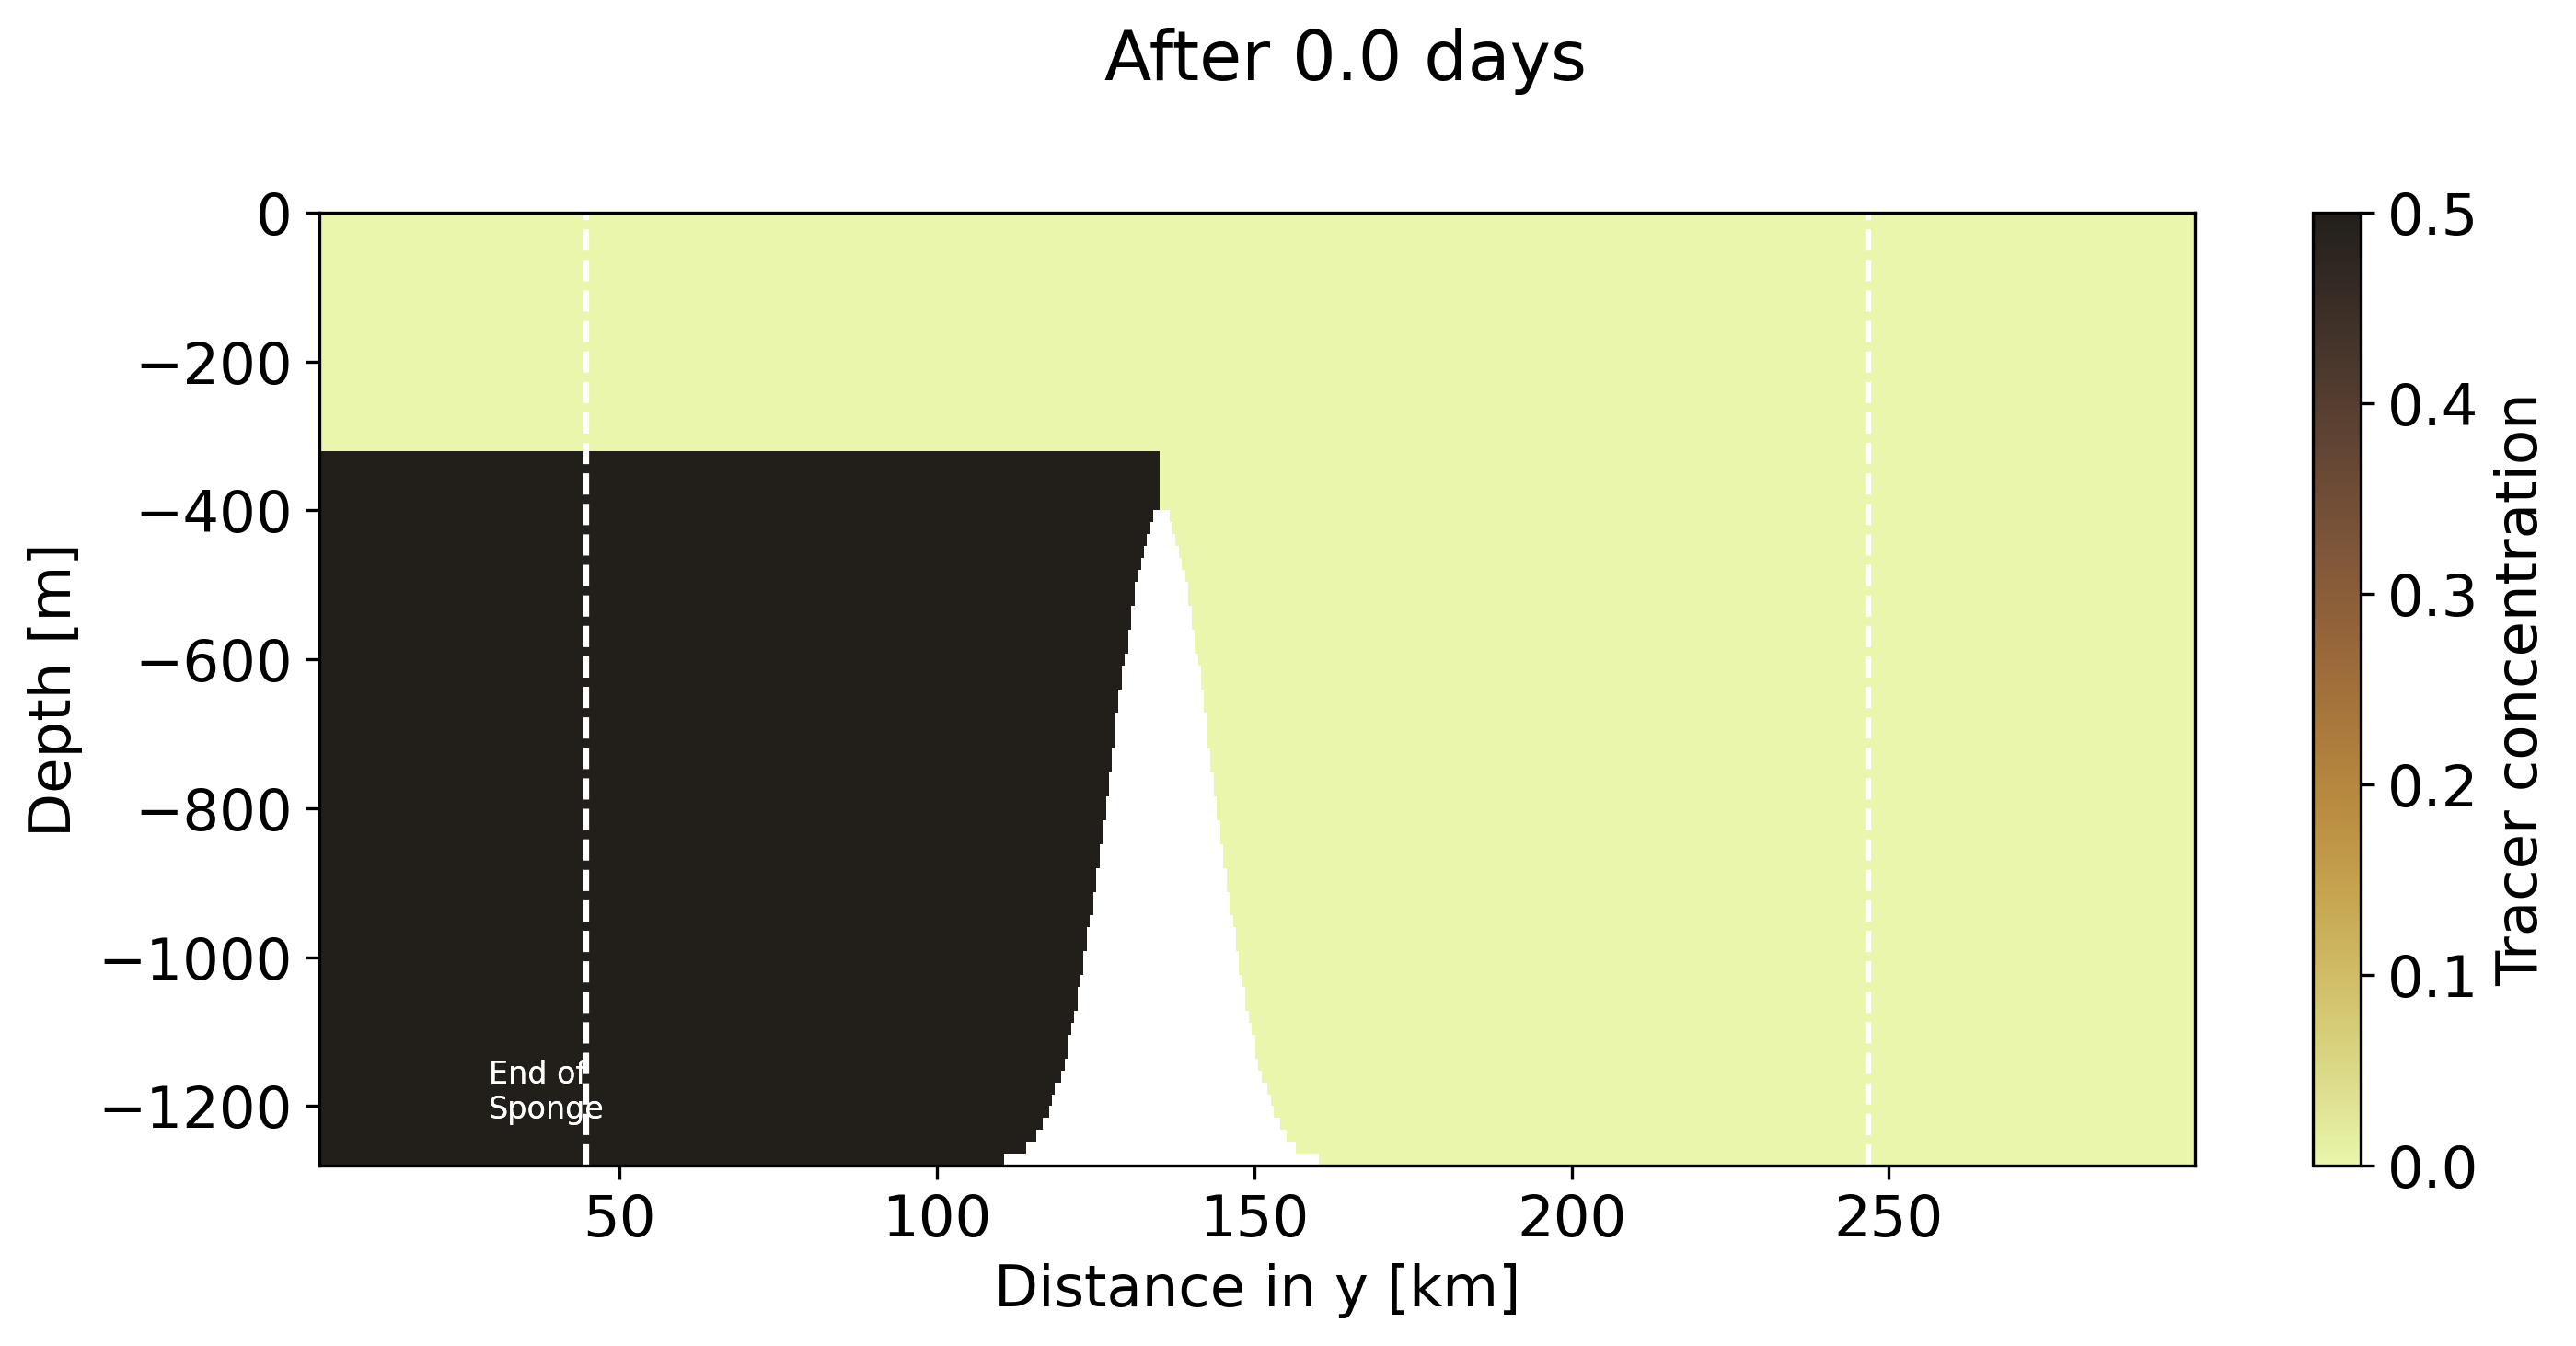

In [110]:
indX=-2
tin=0
fig,axin = plt.subplots()

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=Tracer
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=0
vmax=0.5
cmapi=cmocean.cm.turbid


timein=TIME[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,indX],mask=mask[:,OBp:OBendp,indX]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Tracer concentration')


axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)


fig.suptitle(f'After {0:.1f} days')

fig.tight_layout()
anim = FuncAnimation(fig, animate,frames=np.arange(0,len(TIME),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'tracerDifsmaller.mp4', writer=writer)


## From above 

In [111]:
def BottomConc(vel, hfac, nz,nt, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            for k in range(nx): 
                BotVel[j,i,k] = vel[j,int(BottomInd[i]),i,k] 
                
    
    return (BotVel,BottomInd.astype(int))


In [112]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nt=len(TIME)
nx=len(dsG.X)

tempOut,BottomInd=BottomConc(Tracer,hFacC[:,:,:].values , nz, nt, ny,nx,1)

In [113]:
def animate(t):
    tt=((TIME[t]-TIME[0])/(60*60*24))
    cax1.set_array(np.ma.masked_array(varin[t,dep[0],OB:OBend,OBx:OBendx],mask=mask[dep[0],OB:OBend,OBx:OBendx]))
    cax2.set_array(np.ma.masked_array(varin[t,dep[1],OB:OBend,OBx:OBendx],mask=mask[dep[0],OB:OBend,OBx:OBendx]))
    cax3.set_array(np.ma.masked_array(varin[t,dep[2],OB:OBend,OBx:OBendx],mask=mask[dep[0],OB:OBend,OBx:OBendx]))
    cax4.set_array(tempOut[t,OB:OBend,OBx:OBendx])
    fig.suptitle(f'After {tt:.1f} days',y=0.95)


In [114]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=4, metadata=dict(artist='AM'), bitrate=2000)

In [115]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

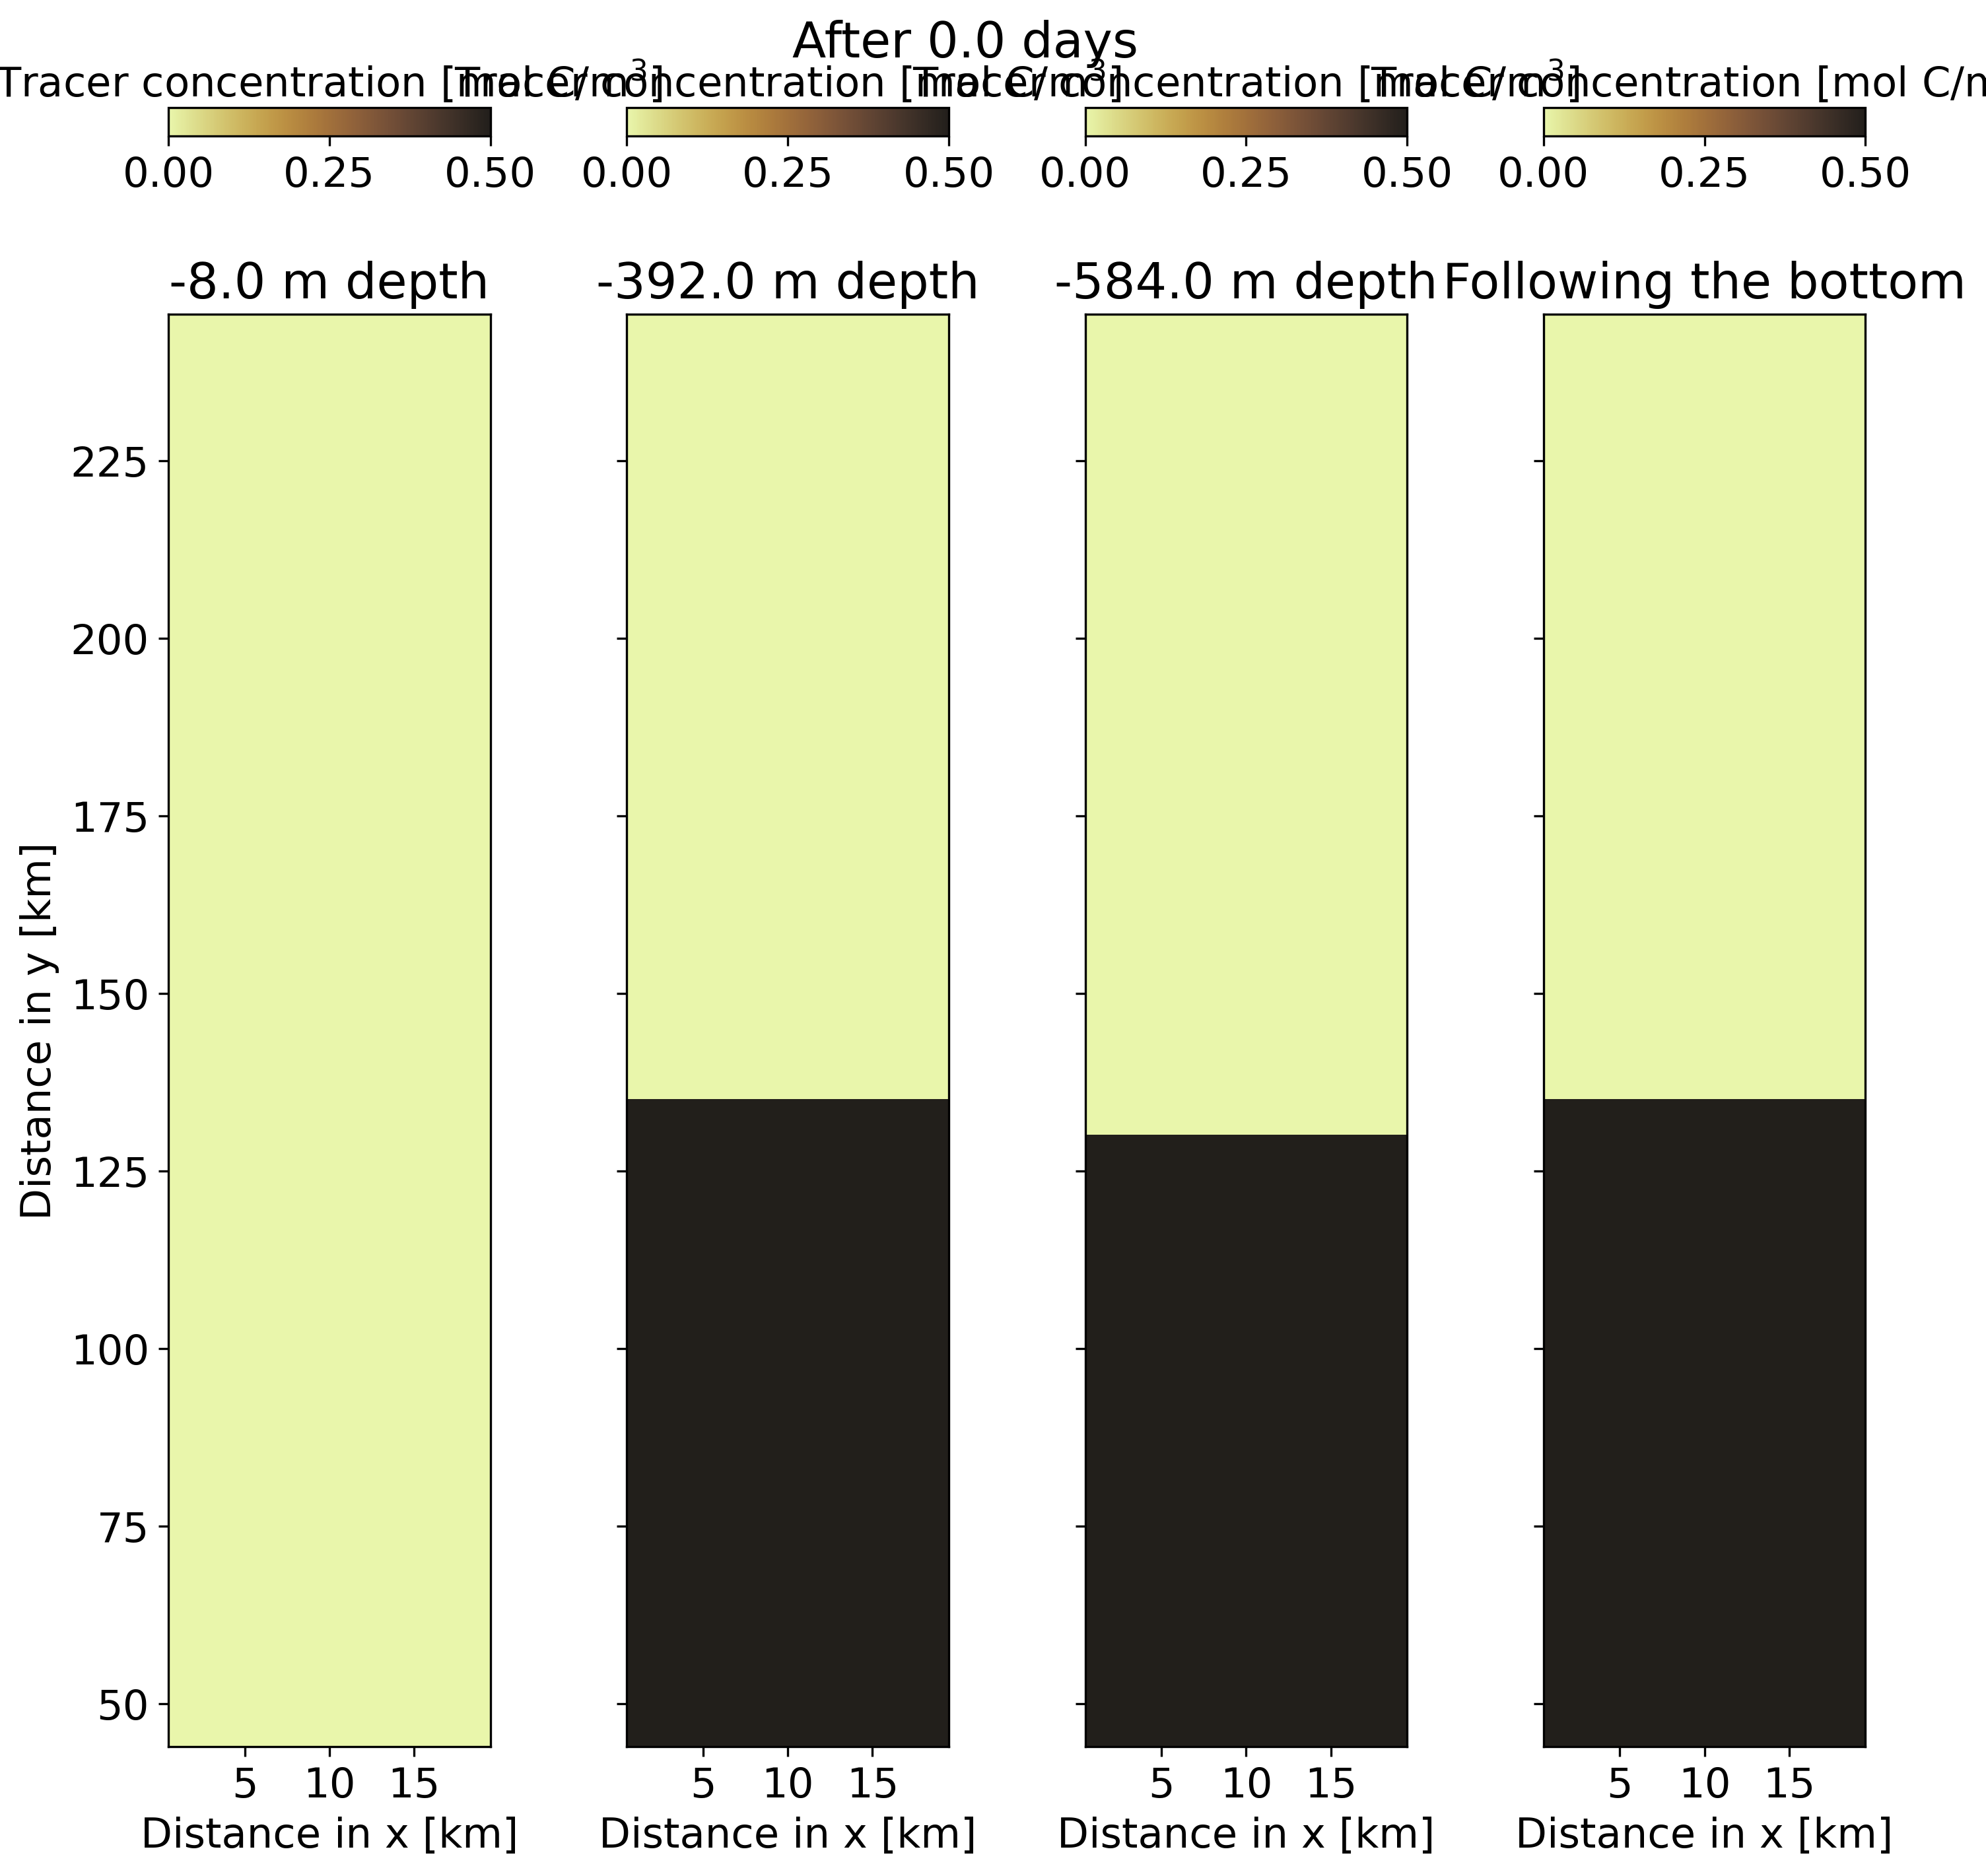

In [116]:
t=0
space=6
dep=[0,np.where(dsG.Z>-400)[0][-1],np.where(dsG.Z>-600)[0][-1]]
VARS=list(ds.keys())[:]
widths = 0.005# np.linspace(0, 2, dsG.X[OBx:OBendx].values.size)

#for variable in VARS:
varin=Tracer
title= 'Tracer concentration [mol C/m$^3$]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.turbid

fig,ax=plt.subplots(1,4)


tin=-1


axin=ax[0]
vmin=0 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=0.5 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax1=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[0]]:.1f} m depth')

'''
gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)

'''
divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax1, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

vmin=0 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
vmax=0.5 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax2=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[1]]:.1f} m depth')

'''
gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)

'''
divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax2, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

vmin=0 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
vmax=0.5 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax3=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[2]]:.1f} m depth')

'''
gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]
-
axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)
'''

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax3, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

vmin= 0#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
vmax= 0.5 #np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax4=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)
'''

gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(vvelOut[start:end,OB:OBend,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(uvelOut[start:end,OB:OBend,:],axis=0))
U=interpU((gridY,gridX))
gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],width=widths)
'''
axin.set(title=f'Following the bottom')


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax4, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)
fig.suptitle(f'After {0:.1f} days')
fig.tight_layout()

anim = FuncAnimation(fig, animate,frames=np.arange(0,len(TIME),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'tracerdifdepthsDifsmaller.mp4', writer=writer)

#fig.patch.set_alpha(0.0)
#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'TracerDifDepths.png', bbox_inches='tight')